## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
import pickle

sys.path.insert(0, "../../../Mamoth")
sys.path.insert(0, "../../../Modules")

from utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 100
pd.options.display.float_format = lambda x: '%.6f' % x

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'

In [4]:
mosquito_data = read_data(f'../data/{NUTS0}_MSQ_culex_2011-2024_processed.csv')

Index(['nuts2', 'nuts3', 'x', 'y', 'dt_placement', 'month', 'year',
       'month_sin', 'month_cos', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean',
       'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std',
       'ndwi_std', 'ndbi_std', 'lst_day', 'lst_night', 'lst',
       'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_jan_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_feb_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_mar_mean',
       'lst_apr_day_mean', 'lst_apr_night_mean', 'lst_apr_mean',
       'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lc_type1', 'mosq_now'],
      dtype='object')


In [5]:
mosquito_data.nuts2.unique()

array(['EL52', 'EL61', 'EL63', 'EL43', 'EL53', 'EL57'], dtype=object)

In [6]:
mosquito_data

,nuts2,nuts3,x,y,dt_placement,month,year,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,lst_jan_day_mean,lst_jan_night_mean,lst_jan_mean,lst_feb_day_mean,lst_feb_night_mean,lst_feb_mean,lst_mar_day_mean,lst_mar_night_mean,lst_mar_mean,lst_apr_day_mean,lst_apr_night_mean,lst_apr_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_type1,mosq_now
0,EL52,EL521,22.193720,40.665896,2011-03-29,3,2011,1.000000,0.000000,0.593170,0.255064,-0.304578,-0.255064,0.543969,0.190812,-0.313988,-0.190812,0.070675,0.095966,0.032384,0.095966,23.170000,7.270000,15.220000,10.020000,-1.467143,4.276429,11.911538,-0.844000,5.533769,19.115714,3.161667,11.138690,24.771667,8.180000,16.475833,203.793588,11.032128,37.117337,21141.266390,883.226446,3,139.431379,26.465763,179.374424,0.000000,1.000000,12,0.000000
1,EL52,EL524,22.447874,40.753947,2011-03-28,3,2011,1.000000,0.000000,0.246762,0.071254,-0.191696,-0.071254,0.264659,0.033256,-0.243740,-0.033256,0.077019,0.067968,0.059814,0.067968,25.110000,9.650000,17.380000,10.408182,-0.333077,5.037552,14.154615,0.016000,7.085308,20.072500,4.233333,12.152917,28.004667,8.736667,18.370667,180.220247,0.072116,37.919265,30069.317203,970.515584,2,153.716334,7.287204,180.413471,0.000000,17.093175,12,32.000000
2,EL52,EL522,22.615797,40.664160,2011-04-05,4,2011,0.866025,-0.500000,0.188915,-0.021250,-0.206622,0.021250,0.179760,-0.054716,-0.234824,0.054716,0.023055,0.028899,0.021619,0.028899,28.530000,6.650000,17.590000,8.797273,-0.459091,4.169091,12.708182,-0.464000,6.122091,18.624286,3.625385,11.124835,28.131333,8.008750,18.070042,231.269478,3.360479,18.171441,16862.084973,3002.814943,2,175.935701,3.944174,180.097455,0.000000,1.251483,9,8.000000
3,EL52,EL525,22.547799,40.509188,2011-04-13,4,2011,0.866025,-0.500000,0.184265,0.061108,-0.126880,-0.061108,0.181648,0.058692,-0.126564,-0.058692,0.011393,0.010442,0.003869,0.010442,26.610000,8.270000,17.440000,9.304286,0.208667,4.756476,11.638333,0.342727,5.990530,18.439231,3.005556,10.722393,25.953333,8.370000,17.161667,224.639889,9.028140,11.736175,4023.105903,244.900503,1,162.125531,9.677160,179.975337,0.000000,130.702755,12,21.000000
4,EL52,EL522,22.715266,40.669967,2011-04-05,4,2011,0.866025,-0.500000,0.362673,0.055860,-0.274874,-0.055860,0.276198,-0.002279,-0.268868,0.002279,0.074791,0.064529,0.032009,0.064529,26.830000,5.690000,16.260000,9.362000,-0.196154,4.582923,12.151667,0.104000,6.127833,18.195000,3.276667,10.735833,26.464118,7.859231,17.161674,222.349577,3.512708,14.843995,10066.399818,2262.772151,0,137.033411,3.910004,179.788315,0.000000,5.966853,12,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20072,EL63,EL632,21.720620,38.225835,2024-09-08,9,2024,-1.000000,-0.000000,-0.030329,-0.036820,0.066883,0.036820,-0.071172,0.105721,0.168866,-0.105721,0.105757,0.186135,0.225935,0.186135,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,168.931756,324.697208,2,166.493709,4.461059,181.900818,0.972635,24.600078,13,1.000000
20073,EL63,EL632,21.725120,38.225193,2024-09-08,9,2024,-1.000000,-0.000000,0.065727,-0.088652,-0.126452,0.088652,0.052458,-0.027046,-0.049954,0.027046,0.109481,0.048347,0.178068,0.048347,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,604.329986,0.000000,46.869999,168.931756,324.697208,2,166.493709,4.461059,181.900818,0.972635,24.600078,13,29.000000
20074,EL63,EL632,21.671776,38.163949,2024-09-08,9,2024,-1.000000,-0.000000,0.233403,-0.049554,-0.288545,0.049554,0.200102,0.049197,-0.175071,-0.049197,0.143922,0.102164,0.232206,0.102164,30.370000,24.070000,27.220000,11.256000,8.323333,9.789667,13.234444,8.488462,10.861453,

In [7]:
# mosquito_data_nuts2 = mosquito_data.query(f"nuts2 == '{NUTS2_EL}'").copy()
# mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [8]:
# mosq_columns = mosquito_data_nuts2.columns
# mosq_columns

In [9]:
# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
#                 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

# columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
#                 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
#                 'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
#                 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
#                 'lst_night', 'acc_rainfall_1week', 'acc_rainfall_2week',
#                 'acc_rainfall_jan', 'mosq_now']

# mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

# mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

In [10]:
mosquito_data = reshape_dataset(mosquito_data,['x','y','dt_placement'])

In [11]:
mosquito_data

,x,y,dt_placement,mosq_now,nuts2,nuts3,month,year,month_sin,month_cos,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst,lst_jan_day_mean,lst_jan_night_mean,lst_jan_mean,lst_feb_day_mean,lst_feb_night_mean,lst_feb_mean,lst_mar_day_mean,lst_mar_night_mean,lst_mar_mean,lst_apr_day_mean,lst_apr_night_mean,lst_apr_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,lc_type1
0,20.772536,38.932006,2024-06-23,7.000000,EL63,EL631,6,2024,0.000000,-1.000000,0.137293,-0.110434,-0.215907,0.110434,0.192877,-0.117798,-0.253381,0.117798,0.067813,0.037356,0.044288,0.037356,36.050000,23.450000,29.750000,11.439333,7.011250,9.225292,11.695000,7.808333,9.751667,15.768947,10.856667,13.312807,21.840000,13.966923,17.903462,621.993077,0.000000,0.000000,511.359452,2946.437192,2,145.794331,0.867053,180.281098,0.475593,1.065210,13
1,20.772536,38.932006,2024-07-08,3.000000,EL63,EL631,7,2024,-0.500000,-0.866025,0.136116,-0.082246,-0.214591,0.082246,0.175884,-0.106449,-0.254290,0.106449,0.070887,0.041583,0.054521,0.041583,34.430000,24.770000,29.600000,11.439333,7.011250,9.225292,11.695000,7.808333,9.751667,15.768947,10.856667,13.312807,21.840000,13.966923,17.903462,621.993077,0.000000,0.000000,511.359452,2946.437192,2,145.794331,0.867053,180.281098,0.475593,1.065210,13
2,20.772536,38.932006,2024-07-21,6.000000,EL63,EL631,7,2024,-0.500000,-0.866025,0.213480,-0.007887,-0.276817,0.007887,0.268138,-0.045527,-0.366267,0.045527,0.057812,0.033454,0.051669,0.033454,34.430000,27.630000,31.030000,11.439333,7.011250,9.225292,11.695000,7.808333,9.751667,15.768947,10.856667,13.312807,21.840000,13.966923,17.903462,621.993077,0.000000,0.000000,511.359452,2946.437192,2,145.794331,0.867053,180.281098,0.475593,1.065210,13
3,20.772536,38.932006,2024-08-04,3.000000,EL63,EL631,8,2024,-0.866025,-0.500000,0.217528,-0.017574,-0.289106,0.017574,0.264545,-0.055466,-0.369753,0.055466,0.051267,0.033734,0.049228,0.033734,34.730000,25.610000,30.170000,11.439333,7.011250,9.225292,11.695000,7.808333,9.751667,15.768947,10.856667,13.312807,21.840000,13.966923,17.903462,621.993077,0.000000,0.000000,511.359452,2946.437192,2,145.794331,0.867053,180.281098,0.475593,1.065210,13
4,20.772536,38.932006,2024-08-18,6.000000,EL63,EL631,8,2024,-0.866025,-0.500000,0.117635,-0.102342,-0.195899,0.102342,0.146791,-0.135776,-0.227748,0.135776,0.055008,0.043494,0.042582,0.043494,30.630000,26.830000,28.730000,11.439333,7.011250,9.225292,11.695000,7.808333,9.751667,15.768947,10.856667,13.312807,21.713158,13.958571,17.835865,864.309978,0.000000,0.000000,511.359452,2946.437192,2,145.794331,0.867053,180.281098,0.475593,1.065210,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15994,26.104770,35.203951,2018-10-14,0.000000,EL43,EL432,10,2018,-0.866025,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.190000,18.430000,21.810000,14.311333,8.223684,11.267509,15.518889,8.602857,12.060873,19.768462,11.120000,15.444231,25.725652,13.505000,19.615326,574.486808,2.518828,3.009228,42.905148,526.523091,5,89.447569,18.500693,174.624011,0.882946,8.670127,13
15995,26.104770,35.203951,2018-10-28,0.000000,EL43,EL432,10,2018,-0.866025,0.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.690000,15.090000,20.390000,14.311333,8.223684,11.267509,15.518889,8.602857,12.060873,19.768462,11.120000,15.444231,25.725652,13.505000,19.615326,590.731095,13.140982,16.244287,42.905148,526.523091,5,89.447569,18.500693,174.624011,0.882946,8.670127,13
15996,26.104770,35.203951,2018-11-13,0.000000,EL43,EL432,11,2018,-0.500000,0.866025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.350000,5.130000,12.240000,14.311333,8.223684,11.267509,15.518889,8.602857,12.060873,19.768462,1

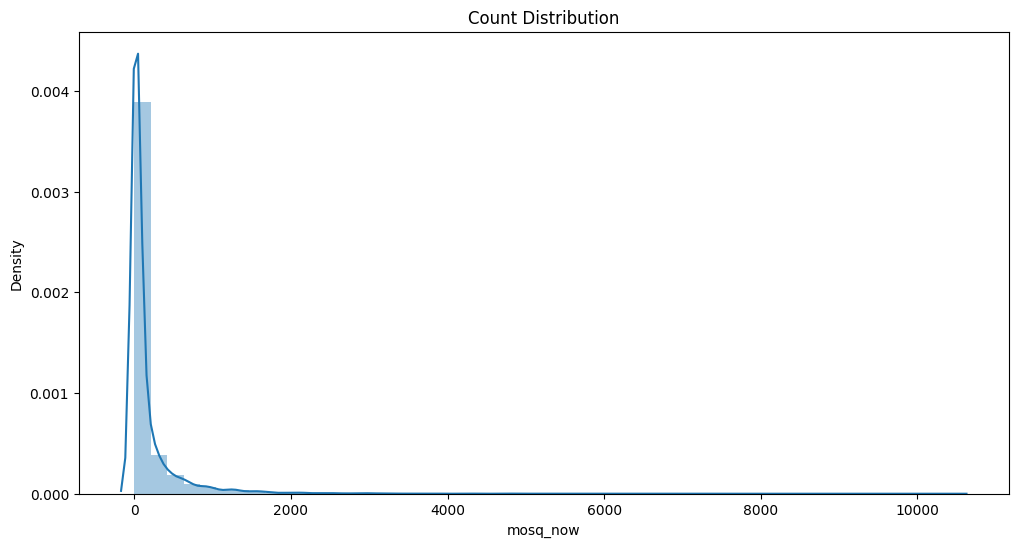

In [12]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [13]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data['mosq_now'].quantile(0.95)

mosquito_data['mosq_now'][mosquito_data['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

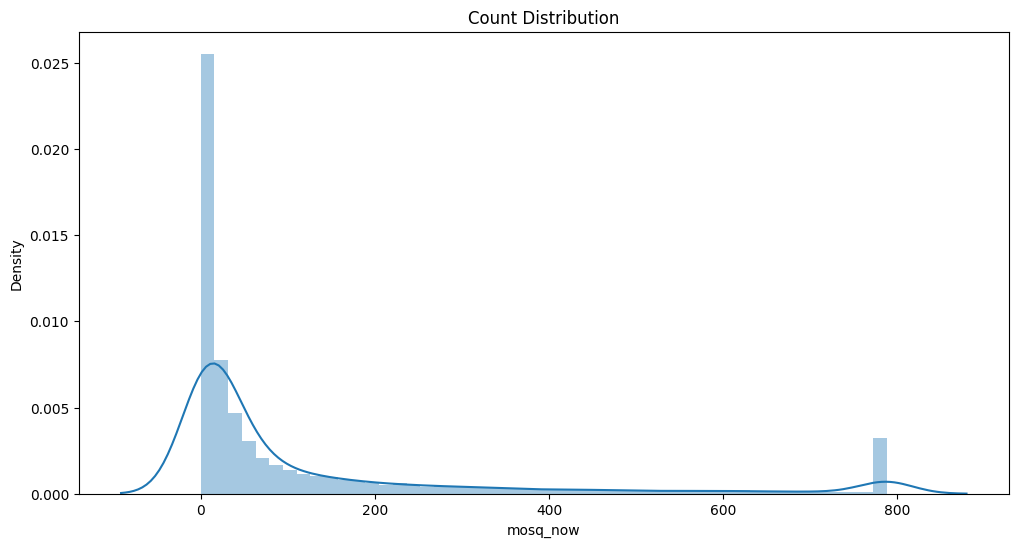

In [14]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data['mosq_now'])
plt.title('Count Distribution')
plt.show()

<Axes: >

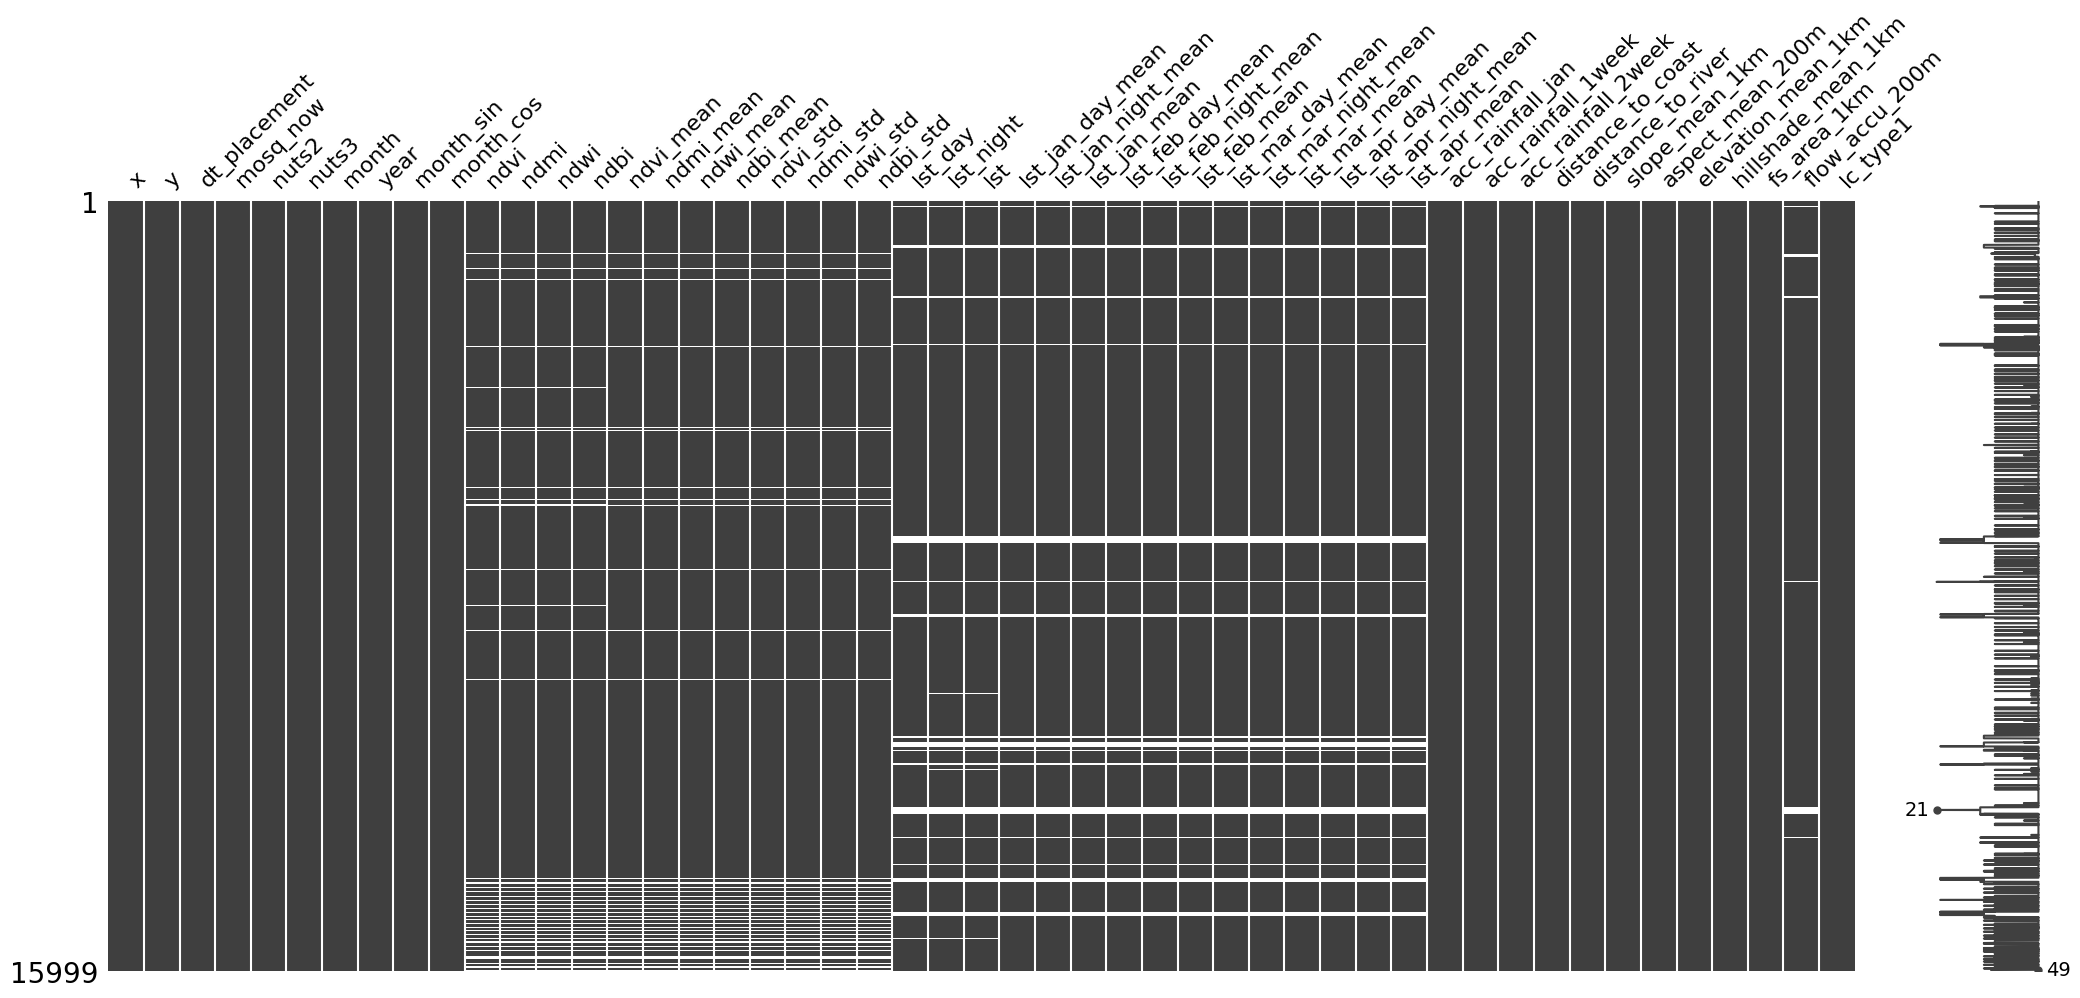

In [15]:
missingno.matrix(mosquito_data)

In [16]:
imputer = KNNImputer()

features_for_impute = [ 'x', 'y', 'month', 'year', 'month_sin', 'month_cos',
                        'ndvi', 'ndmi', 'ndwi', 'ndbi', 
                        'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                        'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst',
                        'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_jan_mean',
                        'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_feb_mean',
                        'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_mar_mean',
                        'lst_apr_day_mean', 'lst_apr_night_mean', 'lst_apr_mean',
                        'acc_rainfall_jan', 'acc_rainfall_1week', 'acc_rainfall_2week',
                        'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
                        'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
                        'fs_area_1km', 'flow_accu_200m', 'lc_type1', 'mosq_now']


mosquito_data_sub = mosquito_data[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [17]:
# imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
#                    'lst_day','lst_night']

imputed_columns = [ 'ndvi', 'ndmi', 'ndwi', 'ndbi',
                    'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 
                    'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 
                    'lst_day', 'lst_night', 'lst',
                    'lst_jan_day_mean', 'lst_jan_night_mean', 'lst_jan_mean',
                    'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_feb_mean',
                    'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_mar_mean',
                    'lst_apr_day_mean', 'lst_apr_night_mean', 'lst_apr_mean',
                    'flow_accu_200m']

mosquito_data[imputed_columns] = imputed_data[imputed_columns]

<Axes: >

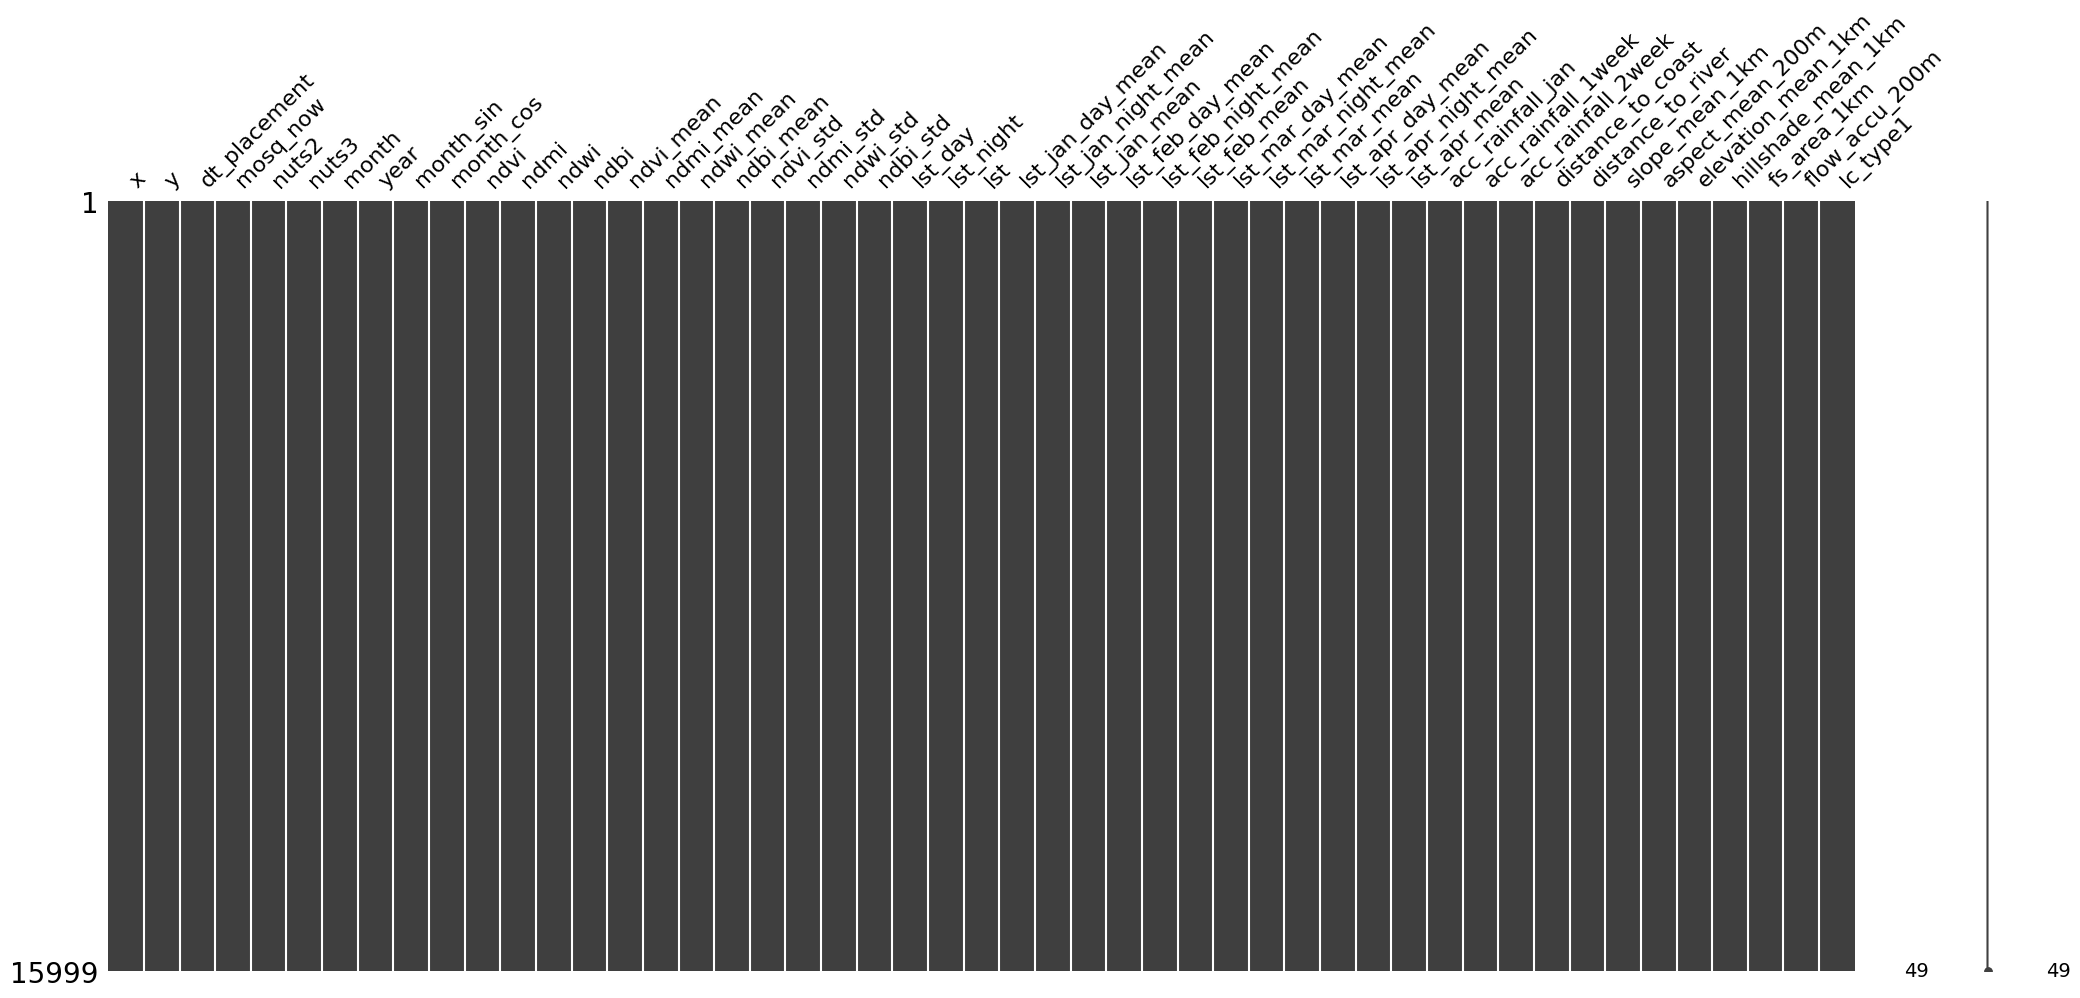

In [18]:
missingno.matrix(mosquito_data)

In [19]:
mosquito_data.drop(columns=['nuts2', 'nuts3'], inplace=True)

In [20]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [21]:
# mosquito_data = initializer(mosquito_data, model_type, 10)

In [22]:
mosquito_data = initializer(mosquito_data,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   27.  788.1]


In [25]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 33.58599 | Val Loss: 44.28069 | Train Acc: 2.893| Val Acc: 3.546
Epoch 002: | Train Loss: 32.88696 | Val Loss: 44.17474 | Train Acc: 2.879| Val Acc: 3.462
Epoch 003: | Train Loss: 32.42161 | Val Loss: 44.10074 | Train Acc: 2.837| Val Acc: 3.412
Epoch 004: | Train Loss: 32.30839 | Val Loss: 44.75777 | Train Acc: 2.811| Val Acc: 3.323
Epoch 005: | Train Loss: 32.24419 | Val Loss: 43.73392 | Train Acc: 2.818| Val Acc: 3.191
Epoch 006: | Train Loss: 32.06024 | Val Loss: 44.92678 | Train Acc: 2.788| Val Acc: 3.283
Epoch 007: | Train Loss: 31.56928 | Val Loss: 44.43279 | Train Acc: 2.731| Val Acc: 3.255
Epoch 008: | Train Loss: 31.23646 | Val Loss: 45.04300 | Train Acc: 2.662| Val Acc: 3.299
Epoch 009: | Train Loss: 31.01249 | Val Loss: 45.08531 | Train Acc: 2.645| Val Acc: 3.294
Epoch 010: | Train Loss: 30.79780 | Val Loss: 45.76724 | Train Acc: 2.604| Val Acc: 3.367
Epoch 011: | Train Loss: 30.61007 | Val Loss: 44.60549 | Train Acc: 2.572| Val Acc: 3.268
Epoch 012:

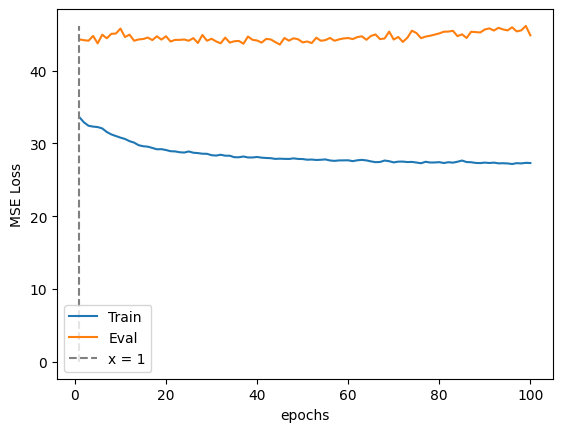

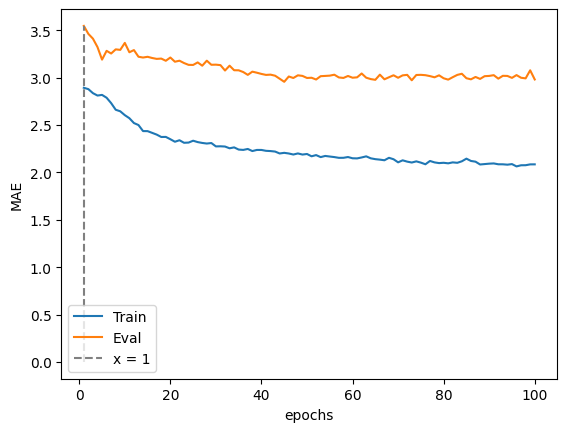

In [27]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 100, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [28]:
metrics(train, test, threshold=30)

MAE on train set:  135.5426315973816
min prediction: 1
max prediction: 760

MAE on test set:  114.39682474661574
Error ⩽ 30: 29.87 %
min prediction: 1
max prediction: 599


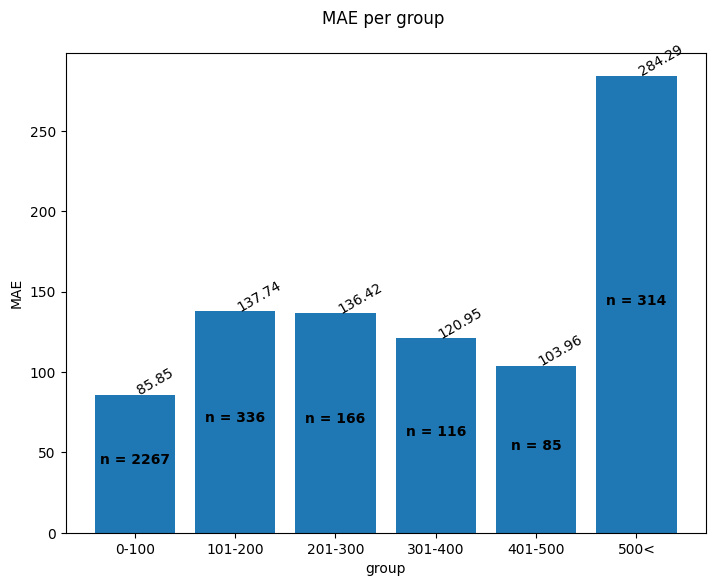

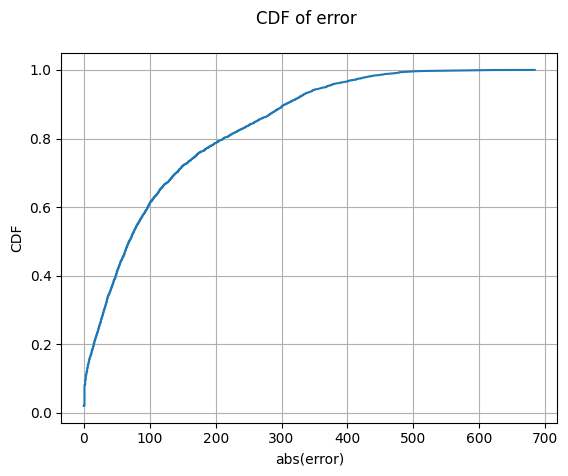

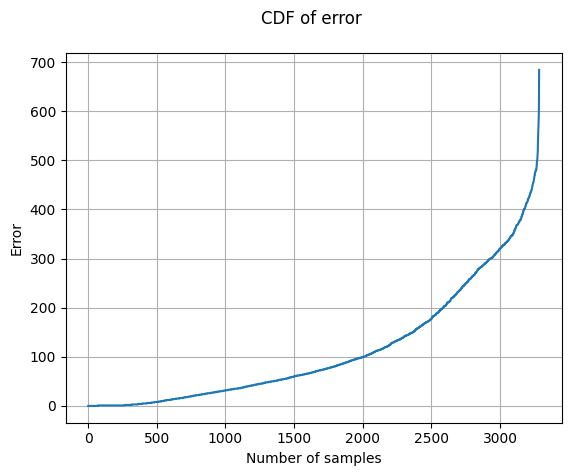

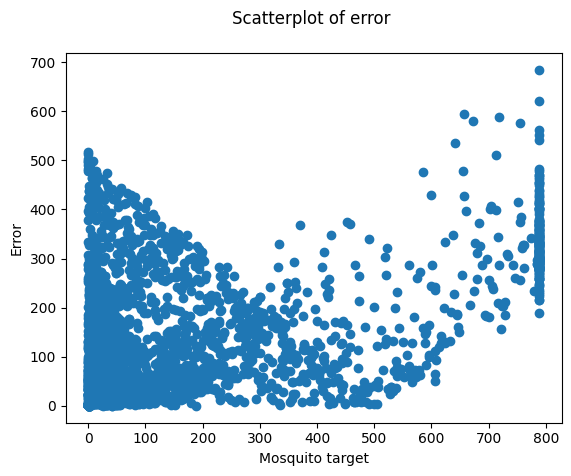

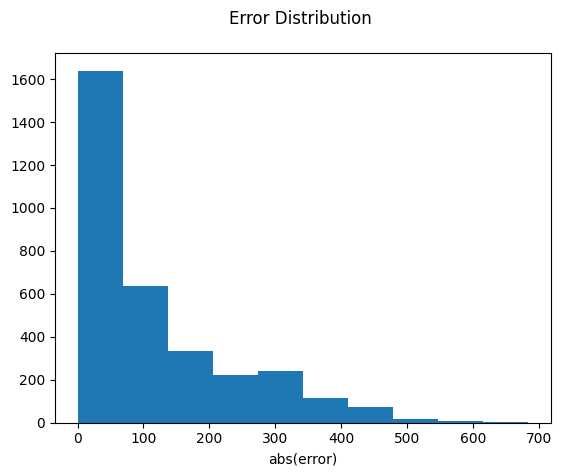

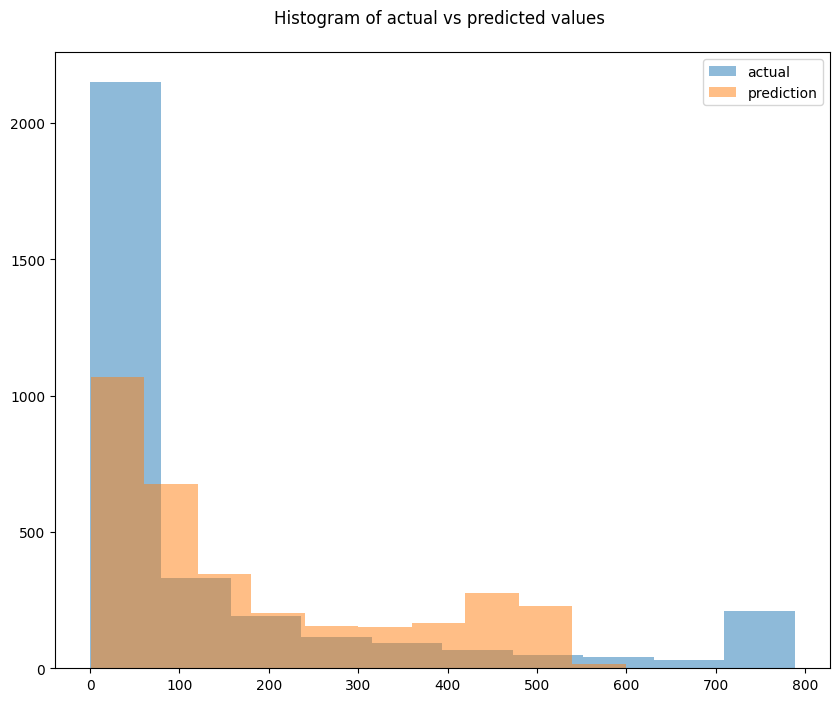

In [29]:
validation_plots(test,model_type)

In [27]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

NameError: name 'mosquito_data_nuts2' is not defined

In [ ]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

NameError: name 'mosquito_data_nuts2' is not defined

In [23]:
pickle.dump(model, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Mamoth_NN.pt', 'wb'))
pickle.dump(imputer, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_KNN_Imputer.pkl', 'wb'))
pickle.dump(scaler, open(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_NUTS3_Culex_Scaler.pkl', 'wb'))